In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Import Libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [ ]:
df = pd.read_csv("fake_job_postings.csv")   # change filename if needed

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (17880, 18)
   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

                                   

Check Missing Values

In [ ]:
print(df.isnull().sum())

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64


Handle Missing Values

In [ ]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for col in text_columns:
    df[col] = df[col].fillna("")

Combine Text Columns

In [ ]:
df["text"] = (
    df["title"] + " " +
    df["company_profile"] + " " +
    df["description"] + " " +
    df["requirements"] + " " +
    df["benefits"]
)

In [ ]:
y = df["fraudulent"]
X = df["text"]

Train-Test Split(strtified)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # important for imbalanced dataset
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (14304,)
Testing size: (3576,)


TF-IDF

In [ ]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (14304, 5000)


Train Logistic Regression Model

In [ ]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"  # important for imbalanced dataset
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

SVM Model

In [ ]:
from sklearn.svm import LinearSVC

# Train SVM model
svm_model = LinearSVC(class_weight="balanced")

svm_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test_tfidf)

# Evaluation
from sklearn.metrics import classification_report, accuracy_score

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nSVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

NameError: name 'X_train_tfidf' is not defined

Accuracy: 0.9704

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3403
           1       0.64      0.90      0.75       173

    accuracy                           0.97      3576
   macro avg       0.82      0.94      0.86      3576
weighted avg       0.98      0.97      0.97      3576

AUC Score: 0.9831


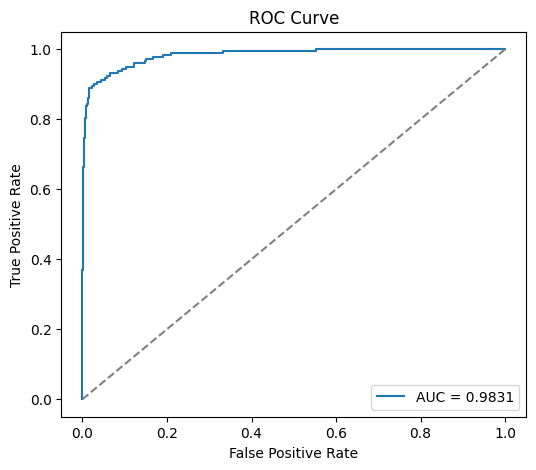

In [ ]:
# ============================
# MODEL EVALUATION
# ============================

from sklearn.metrics import roc_curve, roc_auc_score

# Predictions
y_pred = model.predict(X_test_tfidf)
y_probs = model.predict_proba(X_test_tfidf)[:,1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy,4))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# AUC Score
auc = roc_auc_score(y_test, y_probs)
print("AUC Score:", round(auc,4))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Make Predictions

In [ ]:
y_pred = model.predict(X_test_tfidf)

Evaluate Model

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9703579418344519


Classification Report

In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3403
           1       0.64      0.90      0.75       173

    accuracy                           0.97      3576
   macro avg       0.82      0.94      0.86      3576
weighted avg       0.98      0.97      0.97      3576



Confusion Matrix

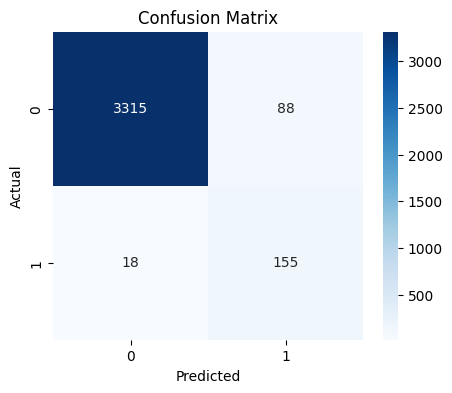

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Test with Custom Job Post

In [ ]:
def predict_job(text):
    text_vec = vectorizer.transform([text])
    probabilities = model.predict_proba(text_vec)[0]

    fake_prob = probabilities[1]
    real_prob = probabilities[0]

    if fake_prob > real_prob:
        print(f"⚠ FAKE Job")
        print(f"Scam Risk Score: {fake_prob:.2f}")
    else:
        print(f"✅ REAL Job")
        print(f"Authenticity Score: {real_prob:.2f}")




sample_job =  """
Software Developer – Full Time

We are looking for a skilled Software Developer to join our growing engineering team in Hyderabad.
The candidate will be responsible for designing, developing, and maintaining web applications using
Java, Spring Boot, and React.

Responsibilities:
- Develop and maintain backend REST APIs
- Collaborate with frontend developers
- Participate in code reviews
- Write clean and efficient code

Requirements:
- Bachelor’s degree in Computer Science or related field
- 2+ years of experience in Java and Spring Boot
- Knowledge of SQL databases
- Good problem-solving skills

Benefits:
- Competitive salary
- Health insurance
- Paid leave
- Performance bonus

This is a full-time on-site position. No application fee required.
"""



predict_job(sample_job)

sample_job = """
Junior Software Developer – Full Time

We are hiring a Junior Software Developer to join our development team.
Candidates must have a Bachelor’s degree in Computer Science.
Experience in Java or Python is preferred.
This is a full-time position with standard company benefits.
No application fee is required.
"""

predict_job(sample_job)

✅ REAL Job
Authenticity Score: 0.66
✅ REAL Job
Authenticity Score: 0.72


In [ ]:
import joblib

joblib.dump(model, "job_scam_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']